# 115.California Housing Price Regression

### 8 개의 독립변수와 1 개의 종속변수 (주택가격 중앙값) 으로 구성

#### 독립변수 (8 개)
MedInc 중간 소득 (단위: $10,000)  
HouseAge 주택 연령 (단위: 년)  
AveRooms 평균 방 개수  
AveBedrms 평균 침실 개수  
Population 인구  
AveOccup 평균 거주자 수  
Latitude 위도  
Longitude 경도  

#### 종속변수 (1 개)
MedHouseVal 주택가격 중앙값 (단위: $100,000)  

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(100)

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Data Load

In [3]:
# California Housing 데이터셋 로드
from sklearn.datasets import fetch_california_housing

# fetch_california_housing을 사용하여 데이터 로드 (DataFrame 형태로)
california_housing = fetch_california_housing(as_frame=True)

# 입력 데이터와 목표 변수 분리
house = california_housing.data  # 입력 특성들 (8개 특성)
target = california_housing.target  # 목표 변수 (주택가격)

## Input / Target 지정

In [4]:
# boston 데이터프레임의 값을 넘파이 배열로 변환하여 X에 저장 (입력 데이터)
X = house.values

# target 데이터프레임의 값을 넘파이 배열로 변환하여 y에 저장 (목표 변수)
y = target.values

# X와 y의 형태(차원)를 출력하여 데이터 크기 확인
X.shape, y.shape

((20640, 8), (20640,))

## Train/Test split

In [5]:
# 데이터를 학습용(train)과 테스트용(test)으로 분할
# test_size=0.2 : 데이터의 20%를 테스트 세트로 사용
# random_state=0 : 실행할 때마다 동일한 데이터 분할을 보장하기 위한 랜덤 시드 설정
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 분할된 데이터셋의 크기(shape)를 출력하여 확인
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(16512, 8) (4128, 8) (16512,) (4128,)


## Feature Scaling

In [6]:
# MinMaxScaler 객체 생성 (각 특성을 최소 0, 최대 1 범위로 스케일링)
sc = MinMaxScaler()

# 학습 데이터(X_train)에 대해 스케일링을 학습(fit)하고 변환(transform) 적용
X_train = sc.fit_transform(X_train)

# 테스트 데이터(X_test)에 대해 동일한 변환(transform) 적용 (fit을 다시 하지 않음)
X_test = sc.transform(X_test)

## Numpy Data를 torch tensor 로 변환

In [7]:
# X_train과 X_test 데이터를 PyTorch의 tensor 형태로 변환 (데이터 타입: float32)
X_train_ts = torch.tensor(X_train, dtype=torch.float32)
X_test_ts = torch.tensor(X_test, dtype=torch.float32)

# y_train과 y_test 데이터를 tensor로 변환하고, 2D 형태로 조정 (열 벡터로 변환)
y_train_ts = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_ts = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# 변환된 텐서들의 크기(shape) 출력
X_train_ts.size(), X_test_ts.size(), y_train_ts.size(), y_test_ts.size()

(torch.Size([16512, 8]),
 torch.Size([4128, 8]),
 torch.Size([16512, 1]),
 torch.Size([4128, 1]))

### Linear Model build
- hidden layer가 한개인 linear regression model

In [8]:
# 개선된 선형 회귀 모델 정의 (4층 구조)
class LinearReg(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)  # 첫 번째 층: input → 128개 뉴런
        self.fc2 = nn.Linear(128, 64)         # 두 번째 층: 128 → 64개 뉴런
        self.fc3 = nn.Linear(64, 32)          # 세 번째 층: 64 → 32개 뉴런
        self.fc4 = nn.Linear(32, output_size)  # 네 번째 층: 32 → output
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)  # 드롭아웃 추가로 과적합 방지

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)  # 드롭아웃 적용
        x = self.relu(self.fc2(x))
        x = self.dropout(x)  # 드롭아웃 적용
        x = self.relu(self.fc3(x))
        x = self.dropout(x)  # 드롭아웃 적용
        output = self.fc4(x)
        return output

## model instance 생성

In [9]:
# 입력 특성 개수(X_train의 열 개수)와 출력 크기(1)를 사용하여 모델 생성
model = LinearReg(X_train.shape[1], 1).to(device)

# 모델 구조 출력
print("모델 구조:")
print(model)

모델 구조:
LinearReg(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)


## 손실함수/optimizer 정의

In [10]:
# 손실 함수 설정 (MSELoss: 평균 제곱 오차 손실 함수)
criterion = nn.MSELoss()

# 최적화 알고리즘 설정 (Adam 옵티마이저, 개선된 학습률 lr=0.0005)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

### Dataset Loader 생성

- torch.utils.data.TensorDataset : Dataset wrapping tensors

In [11]:
# TensorDataset 생성 (X_train_ts: 입력 데이터, y_train_ts: 정답 레이블)
train_ds = torch.utils.data.TensorDataset(X_train_ts, y_train_ts)

# DataLoader 생성 (개선된 설정)
# - batch_size=64 : 한 번에 64개 샘플씩 미니배치를 구성 (더 안정적인 학습)
# - shuffle=True : 데이터 순서를 섞어서 학습 성능 향상
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

## The training process
- Batch data Load
- model 을 이용하여 batch data 예측  
- loss value 계산
- optimizer 에 저장된 grad value clear
- loss value backpropagate
- optimizer update  

In [12]:
# 손실 값을 저장할 리스트 초기화
Loss = []
# 학습 반복 횟수 설정
num_epochs = 100

# 학습 루프 시작
for epoch in range(num_epochs):
    epoch_loss = 0.0  # 에포크별 평균 손실 계산을 위한 변수
    num_batches = 0   # 배치 수 카운터

    for x, y in train_loader:      # 미니배치 단위로 데이터 로드
        x, y = x.to(device), y.to(device)  # 데이터를 GPU 또는 CPU로 이동
        yhat = model(x)                # 모델의 예측값 계산
        loss = criterion(yhat, y)     # 손실 값 계산

        optimizer.zero_grad()       # 기존 그래디언트 초기화
        loss.backward()               # 역전파 수행 (그래디언트 계산)
        optimizer.step()               # 가중치 업데이트
        
        epoch_loss += loss.item()    # 에포크별 손실 누적
        num_batches += 1             # 배치 수 증가

    # 에포크별 평균 손실 계산 및 출력
    avg_loss = epoch_loss / num_batches
    if (epoch + 1) % 10 == 0:  # 10 에포크마다 출력
        print("epoch {} avg_loss: {:.4f}".format(epoch + 1, avg_loss))

    # 평균 손실 값을 리스트에 저장
    Loss.append(avg_loss)

epoch 10 avg_loss: 0.5364
epoch 20 avg_loss: 0.4740
epoch 30 avg_loss: 0.4321
epoch 40 avg_loss: 0.4040
epoch 50 avg_loss: 0.3845
epoch 60 avg_loss: 0.3605
epoch 70 avg_loss: 0.3456
epoch 80 avg_loss: 0.3337
epoch 90 avg_loss: 0.3254
epoch 100 avg_loss: 0.3191


## Test set을 이용하여 model 평가

In [13]:
# 테스트 데이터(X_test_ts)를 모델에 입력하여 예측값을 얻고, 손실(MSELoss) 계산
test_loss = criterion(model(X_test_ts.to(device)), y_test_ts.to(device)).item()

# 테스트 데이터에 대한 최종 손실 출력
print(test_loss)

0.3324342966079712


Loss 시각화

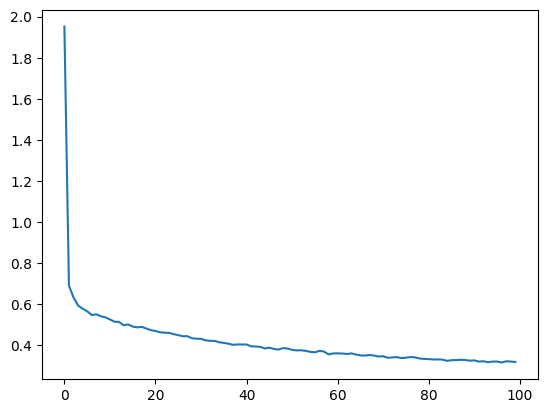

In [14]:
plt.plot(Loss)

Test set을 이용하여 예측

In [15]:
# 테스트 데이터(X_test_ts)를 모델에 입력하여 예측 수행 (디바이스에 맞게 변환)
y_pred = model(X_test_ts.to(device)).numpy(force=True)
y_pred.shape

(4128, 1)

MSE, R2 계산

In [16]:
from sklearn.metrics import mean_squared_error, r2_score  # 성능 평가 지표 임포트

# 평균 제곱 오차(MSE) 계산 및 출력
print(mean_squared_error(y_test, y_pred))

# 결정 계수(R² Score) 계산 및 출력
print(r2_score(y_test, y_pred))

0.31952137785414547
0.7549597940182348


True vs. Predicted 시각화

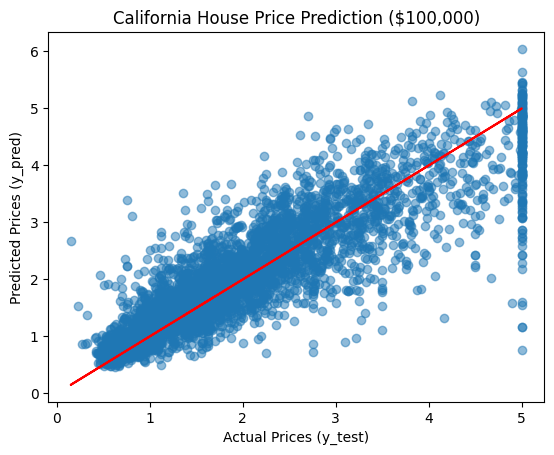

In [17]:
# 실제값(y_test)과 예측값(y_pred)의 산점도 그리기
plt.scatter(y_test, y_pred, alpha=0.5)  # 투명도(alpha) 조정으로 시각적 가독성 향상

# 완벽한 예측(예측값 = 실제값)을 나타내는 기준선 추가 (빨간색 선)
plt.plot(y_test, y_test, 'r')

# 그래프 레이블 및 제목 설정
plt.xlabel('Actual Prices (y_test)')          # x축: 실제 주택 가격
plt.ylabel('Predicted Prices (y_pred)')    # y축: 예측된 주택 가격
plt.title('California House Price Prediction ($100,000)')

plt.show()